# **New York City Taxi Fare Prediction** #

# **I. Pendahuluan**

Dataset ini berisi data perjalanan taxi di New York City, dengan beberapa informasi penting seperti pickup_datetime, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, passenger_count, dan tentu saja fare_amount yang jadi target dari prediksi kita.

Setiap baris merepresentasikan satu perjalanan taxi, dan data ini bisa digunakan untuk mempelajari pola-pola perjalanan, pricing behavior, dan bahkan aspek geografis dari kota NYC. Proyek ini fokus untuk membangun model machine learning yang bisa memprediksi tarif taxi hanya berdasarkan informasi yang tersedia sebelum perjalanan terjadi.

Tujuan: Regresi

Memprediksi fare amount (jumlah tarif) dari suatu perjalanan taxi berdasarkan fitur-fitur seperti lokasi pickup dan dropoff, waktu, dan jumlah penumpang.

# **II. Paparan data**


## *II.a Library*

In [30]:
import os

# Pindah ke folder D:
os.chdir("D:/Kuliah/Taxi")

# Lihat isi folder untuk cek
print(os.listdir())


['GCP-Coupons-Instructions.rtf', 'sample_submission.csv', 'test.csv', 'train.csv']


In [59]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import radians, cos, sin, asin, sqrt, atan2
from pyspark.sql.functions import col, mean as _mean, stddev as _std
from pyspark.sql.functions import col, when, count
from pyspark.sql.functions import col, year, month, dayofmonth, hour, minute, second, dayofweek, to_timestamp
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## *II.b Dataset*

In [32]:
spark = SparkSession.builder \
    .appName("TaxiProject") \
    .config("spark.local.dir", "D:/spark-temp") \
    .getOrCreate()

df = spark.read.csv("D:/Kuliah/Taxi/train.csv", header=True, inferSchema=True) \
         .limit(1000000)

df.show(5)

df.printSchema()


+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|                key|fare_amount|    pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:21|        4.5|2009-06-16 00:26:21|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:16|       16.9|2010-01-05 23:52:16|      -74.016048|      40.711303|       -73.979268|       40.782004|              1|
|2011-08-18 00:35:00|        5.7|2011-08-18 07:35:00|      -73.982738|       40.76127|       -73.991242|       40.750562|              2|
|2012-04-21 04:30:42|        7.7|2012-04-21 11:30:42|       -73.98713|      40.733143|       -73.991567|       40.758092|              1|
|2010-03-09 07:51:00|        5.3|2

## *II.c Data Cleaning*

In [33]:
df = df.dropDuplicates()

In [34]:
df.select("fare_amount").describe().show()

+-------+-----------------+
|summary|      fare_amount|
+-------+-----------------+
|  count|          1000000|
|   mean|11.34807872000041|
| stddev|9.822090134942536|
|    min|            -44.9|
|    max|            500.0|
+-------+-----------------+



In [35]:
df.select("passenger_count").describe().show()

+-------+------------------+
|summary|   passenger_count|
+-------+------------------+
|  count|           1000000|
|   mean|          1.684924|
| stddev|1.3239112005587288|
|    min|                 0|
|    max|               208|
+-------+------------------+



In [36]:
# Check for missing values
missing_values = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
missing_values.show()

+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|               10|              10|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



In [37]:
# Remove rows with missing values
df = df.dropna()

# Filter out rows with negative fares or zero passengers
df = df.filter((df.fare_amount > 0) & (df.passenger_count <= 6 ))

Convert to Distance

In [40]:
# Radius bumi dalam kilometer
R = 6371.0

# Hitung distance dalam kilometer dengan Haversine
df = df.withColumn("pickup_lat_rad", radians(col("pickup_latitude"))) \
       .withColumn("dropoff_lat_rad", radians(col("dropoff_latitude"))) \
       .withColumn("pickup_lon_rad", radians(col("pickup_longitude"))) \
       .withColumn("dropoff_lon_rad", radians(col("dropoff_longitude"))) \
       .withColumn("dlat", col("dropoff_lat_rad") - col("pickup_lat_rad")) \
       .withColumn("dlon", col("dropoff_lon_rad") - col("pickup_lon_rad")) \
       .withColumn("a", sin(col("dlat")/2)**2 + cos(col("pickup_lat_rad")) * cos(col("dropoff_lat_rad")) * sin(col("dlon")/2)**2) \
       .withColumn("c", 2 * atan2(sqrt(col("a")), sqrt(1 - col("a")))) \
       .withColumn("distance", R * col("c"))


In [47]:
df = df.drop("pickup_lat_rad", "dropoff_lat_rad", "pickup_lon_rad", "dropoff_lon_rad", "dlat", "dlon", "a", "c")


In [41]:
# Ubah kolom 'key' ke tipe timestamp
df = df.withColumn("key", to_timestamp("key"))

# Ekstrak bagian waktu
df = df.withColumn("year", year(col("key"))) \
       .withColumn("month", month(col("key"))) \
       .withColumn("day", dayofmonth(col("key"))) \
       .withColumn("hour", hour(col("key"))) \
       .withColumn("minute", minute(col("key"))) \
       .withColumn("second", second(col("key"))) \
       .withColumn("day_of_week", dayofweek(col("key")))  # Note: Minggu = 1, Senin = 2, dst


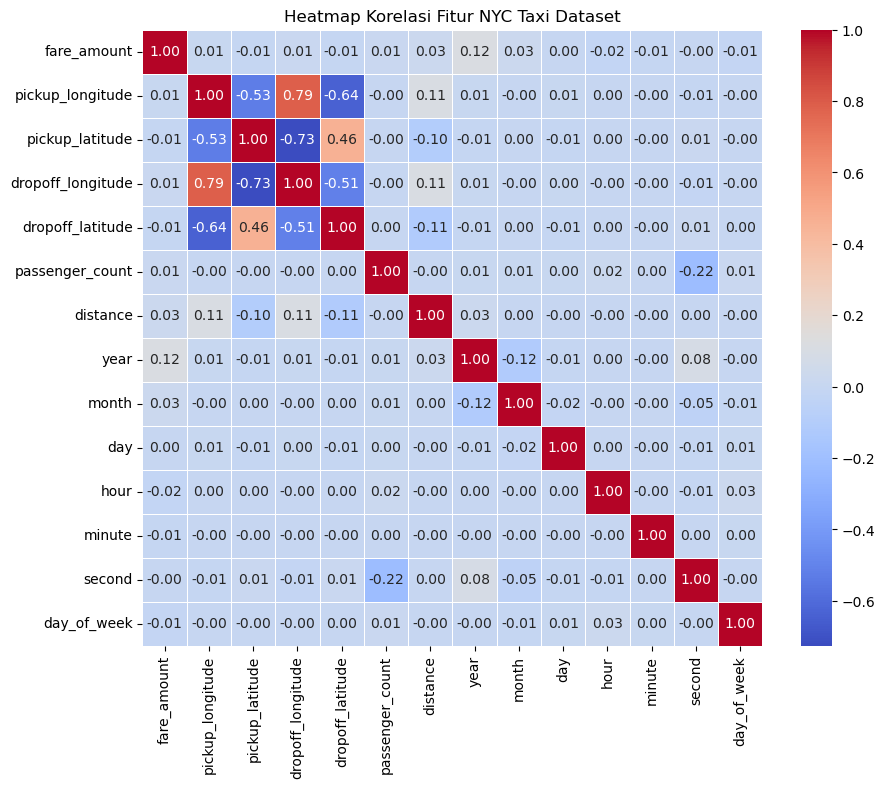

In [42]:
# Pilih kolom numerik
numeric_cols = ['fare_amount', 'pickup_longitude', 'pickup_latitude', 
                'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distance', 'year', 'month', 'day', 'hour', 'minute', 'second', 'day_of_week']

# Gabungkan jadi satu kolom vektor
vec_assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
df_vector = vec_assembler.transform(df).select("features")

# Hitung korelasi
correlation_matrix = Correlation.corr(df_vector, "features", "pearson").head()[0]
corr_array = correlation_matrix.toArray()

# Ubah ke pandas dataframe
corr_df = pd.DataFrame(corr_array, index=numeric_cols, columns=numeric_cols)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur NYC Taxi Dataset")
plt.show()


In [45]:
df = df.drop("key", "pickup_datetime", "second")

In [44]:
df = df.drop("pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude")

In [48]:
df.show(5)

+-----------+---------------+------------------+----+-----+---+----+------+-----------+
|fare_amount|passenger_count|          distance|year|month|day|hour|minute|day_of_week|
+-----------+---------------+------------------+----+-----+---+----+------+-----------+
|        4.5|              1| 1.030763935049508|2009|    6| 15|  17|    26|          2|
|       16.9|              1| 8.450133595805992|2010|    1|  5|  16|    52|          3|
|        5.7|              2|1.3895252257697308|2011|    8| 18|   0|    35|          5|
|        7.7|              1| 2.799270239983641|2012|    4| 21|   4|    30|          7|
|        5.3|              1|1.9991567879963377|2010|    3|  9|   7|    51|          3|
+-----------+---------------+------------------+----+-----+---+----+------+-----------+
only showing top 5 rows



## *II.d Visualization & Exploratory Data Analysis (EDA)*

## *II.e Data Pre-processing*

Tidak memerlukan normalisasi

In [55]:
# Siapkan fitur x
feature_cols = ['passenger_count', 'distance', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week']

# Gabungkan fitur ke dalam kolom "features", target tetap "fare_amount"
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_model = assembler.transform(df).select("features", "fare_amount")


## *II.f Data Training dan Testing*


In [56]:
# Split train dan test
train_data, test_data = df_model.randomSplit([0.7, 0.3], seed=20)

# Tampilkan X_train dan y_train
print("Isi x_train:")
train_data.select("features").show(5, truncate=False)

print("\nIsi y_train:")
train_data.select("fare_amount").show(5)

# Tampilkan X_test dan y_test
print("\nIsi x_test:")
test_data.select("features").show(5, truncate=False)

print("\nIsi y_test:")
test_data.select("fare_amount").show(5)


Isi x_train:
+----------------------------------------+
|features                                |
+----------------------------------------+
|[0.0,0.0,2010.0,11.0,22.0,7.0,16.0,2.0] |
|[0.0,0.0,2010.0,12.0,13.0,10.0,51.0,2.0]|
|[0.0,0.0,2011.0,1.0,29.0,8.0,52.0,7.0]  |
|[0.0,0.0,2011.0,3.0,16.0,17.0,55.0,4.0] |
|[0.0,0.0,2011.0,4.0,7.0,14.0,31.0,5.0]  |
+----------------------------------------+
only showing top 5 rows


Isi y_train:
+-----------+
|fare_amount|
+-----------+
|        8.9|
|        6.1|
|       50.0|
|        4.5|
|       24.5|
+-----------+
only showing top 5 rows


Isi x_test:
+----------------------------------------+
|features                                |
+----------------------------------------+
|[0.0,0.0,2010.0,12.0,21.0,12.0,27.0,3.0]|
|[0.0,0.0,2011.0,5.0,6.0,22.0,3.0,6.0]   |
|[0.0,0.0,2011.0,6.0,12.0,16.0,16.0,1.0] |
|[0.0,0.0,2011.0,6.0,23.0,8.0,20.0,5.0]  |
|[0.0,0.0,2011.0,9.0,15.0,12.0,56.0,5.0] |
+----------------------------------------+
only showi

# **III. Metode: Decision Tree & Random Forest Regressor**


## *III.a Modelling Decision Tree*

In [58]:
# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeRegressor(featuresCol="features", labelCol="fare_amount")
dt_model = dt.fit(train_data)

# Prediksi terhadap data test
dt_predictions = dt_model.transform(test_data)

# Evaluasi model dengan RMSE
evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
rmse_dt = evaluator.evaluate(dt_predictions)
print(f"RMSE Decision Tree: {rmse_dt}")

# Tampilkan beberapa hasil prediksi vs nilai asli
dt_predictions.select("prediction", "fare_amount").show(10)


RMSE Decision Tree: 5.6332138687853
+-----------------+-----------+
|       prediction|fare_amount|
+-----------------+-----------+
|10.26994862146319|        9.7|
|10.26994862146319|       24.4|
|10.26994862146319|       12.9|
|10.26994862146319|        5.7|
|10.26994862146319|        4.9|
|10.26994862146319|        2.5|
|10.26994862146319|        5.7|
|10.26994862146319|        3.7|
|10.26994862146319|        4.1|
|10.26994862146319|        6.1|
+-----------------+-----------+
only showing top 10 rows



## *III.b Random Forest Regressor*

In [61]:
# Siapkan model Random Forest
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="fare_amount",
    numTrees=70,        # jumlah pohon, bisa dikurangi kalau training lambat
    maxDepth=10,         # kedalaman maksimum tiap pohon
    seed=42
)

# Latih model dengan data training
rf_model = rf.fit(train_data)

# Prediksi terhadap data test
rf_predictions = rf_model.transform(test_data)

# Evaluasi model dengan RMSE
evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
rmse_rf = evaluator.evaluate(rf_predictions)
print(f"RMSE Random Forest: {rmse_rf}")

# Tampilkan beberapa hasil prediksi vs nilai asli
rf_predictions.select("prediction", "fare_amount").show(10)


Py4JJavaError: An error occurred while calling o1113.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 240.0 failed 1 times, most recent failure: Lost task 0.0 in stage 240.0 (TID 2228) (LAPTOP-N54IMBKK executor driver): TaskResultLost (result lost from block manager)
Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2856)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2792)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2791)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2791)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFaile

# **IV. Evaluation**

# **V. Tuning Hyperparameter**

# **VI. Kesimpulan**